In [ ]:
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

import os
import random
import math

import numpy as np
import librosa
import librosa.display

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Function to extract audio features
def extract_features_approach2(audio_path, sr=16000, duration=2.0, n_fft=2048, hop_length=512, n_mels=128, n_mfcc=40):
    # Load audio file
    y, sr = librosa.load(audio_path, sr=sr, duration=duration)
    
    # Extract harmonic component
    y_harmonic = librosa.effects.harmonic(y)
    
    # Compute spectral contrast
    sc = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    sc_mean = np.mean(sc, axis=1)
    
    # Compute tonnetz
    chroma_cq = librosa.feature.chroma_cqt(y=y_harmonic, sr=sr)
    tonnetz = librosa.feature.tonnetz(chroma=chroma_cq)
    tonnetz_mean = np.mean(tonnetz, axis=1)
    
    # Compute chroma
    chroma_stft = librosa.feature.chroma_stft(y=y_harmonic, sr=sr, n_fft=n_fft, hop_length=hop_length)
    chroma_mean = np.mean(chroma_stft, axis=1)
    
    # Compute Mel spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_mean = np.mean(mel_db, axis=1)
    
    # Compute MFCC features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    mfcc_mean = np.mean(mfcc, axis=1)
    
    # All extracted features into a single feature vector
    features = np.hstack([sc_mean, tonnetz_mean, chroma_mean, mel_mean, mfcc_mean])
    
    # Normalize
    features -= np.mean(features)
    std = np.std(features)
    if std > 1e-12:
        features /= std
    
    return features

In [ ]:
# Generator function for streaming audio during training
def audio_data_generator_approach2(paths, labels, batch_size=32, shuffle=True):
    num_files = len(paths)
    
    while True:
        if shuffle:
            # Shuffle data
            combined = list(zip(paths, labels))
            random.shuffle(combined)
            paths, labels = zip(*combined)
        
        for i in range(0, num_files, batch_size):
            # Create batch
            batch_paths = paths[i:i + batch_size]
            batch_labels = labels[i:i + batch_size]
            
            feature_list = []
            label_list = []
            
            for path, lbl in zip(batch_paths, batch_labels):
                # Extract features
                feat = extract_features_approach2(path)
                if feat is not None:
                    feat = np.expand_dims(feat, axis=-1)
                    feature_list.append(feat)
                    label_list.append(lbl)
            
            if len(feature_list) == 0:
                continue
            
            # Convert batch into numpy arrays
            X_batch = np.array(feature_list, dtype=np.float32)
            y_batch = np.array(label_list, dtype=np.float32)
            
            yield X_batch, y_batch

In [ ]:
gunshot_path = r"C:\Users\jakem\Desktop\gunshot-detection-main\NewSVMAttempt\SVMDATA\svmgunshot"
non_gunshot_path = r"C:\Users\jakem\Desktop\gunshot-detection-main\NewSVMAttempt\SVMDATA\svmnot-gunshot"
print(os.path.exists(gunshot_path))
print(os.path.exists(non_gunshot_path))

# Function to load audio
def load_audio_paths(path, label):
    data = []
    if not os.path.exists(path):
        print(f"Warning: Path {path} does not exist.")
        return data
    for wav_file in Path(path).rglob("*.wav"):
        data.append((str(wav_file), label))
    return data

# Load audio paths and assign labels
gunshot_data = load_audio_paths(gunshot_path, 1)
non_gunshot_data = load_audio_paths(non_gunshot_path, 0)

# Combine and shuffle
all_data = gunshot_data + non_gunshot_data
random.shuffle(all_data)

# Extract file paths and labels
filepaths = [pair[0] for pair in all_data]
labels = [pair[1] for pair in all_data]

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(filepaths, labels, test_size=0.2, random_state=42)

# Print statistics
print(f"# training samples: {len(X_train)}")
print(f"# validation samples: {len(X_val)}")

True
True
# training samples: 11184
# validation samples: 2797


In [ ]:
# Determine feature dimension
from tqdm.auto import tqdm
temp_feat = None
for fp in tqdm(X_train):
    temp_feat = extract_features_approach2(fp)
    if temp_feat is not None:
        break
feature_dim = temp_feat.shape[0]
print("Feature vector dimension:", feature_dim)

  0%|          | 0/11184 [00:00<?, ?it/s]

Feature vector dimension: 193


c:\Users\jakem\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=500
  warnings.warn(


In [ ]:
# 1D CNN model
model = models.Sequential([
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(feature_dim, 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_12 (Conv1D)          (None, 191, 32)           128       
                                                                 
 max_pooling1d_12 (MaxPooli  (None, 95, 32)            0         
 ng1D)                                                           
                                                                 
 conv1d_13 (Conv1D)          (None, 93, 64)            6208      
                                                                 
 max_pooling1d_13 (MaxPooli  (None, 46, 64)            0         
 ng1D)                                                           
                                                                 
 conv1d_14 (Conv1D)          (None, 44, 128)           24704     
                                                                 
 max_pooling1d_14 (MaxPooli  (None, 22, 128)          

In [ ]:
# Training parameters
batch_size = 32
train_gen = audio_data_generator_approach2(X_train, y_train, batch_size=batch_size, shuffle=True)
val_gen   = audio_data_generator_approach2(X_val, y_val, batch_size=batch_size, shuffle=False)

steps_per_epoch   = math.ceil(len(X_train) / batch_size)
validation_steps  = math.ceil(len(X_val)   / batch_size)

checkpoint_path = "training_checkpoints_approach2/cp-{epoch:04d}.ckpt"
cp_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(train_gen,steps_per_epoch=steps_per_epoch,epochs=25,validation_data=val_gen,validation_steps=validation_steps,callbacks=[early_stop, cp_callback],verbose=1)

NameError: name 'audio_data_generator_approach2' is not defined

In [ ]:
# Save model
model_name = "SVMAtp1"
model.save(f"../models/{model_name}.h5")

c:\Users\jakem\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


c:\Users\jakem\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=500
  warnings.warn(
c:\Users\jakem\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


1/1 [==============================] - 0s 15ms/step
Confusion Matrix:
[[2000   46]
 [  46  705]]

Classification Report:
              precision    recall  f1-score   support

 Non-Gunshot       0.98      0.98      0.98      2046
     Gunshot       0.94      0.94      0.94       751

    accuracy                           0.97      2797
   macro avg       0.96      0.96      0.96      2797
weighted avg       0.97      0.97      0.97      2797



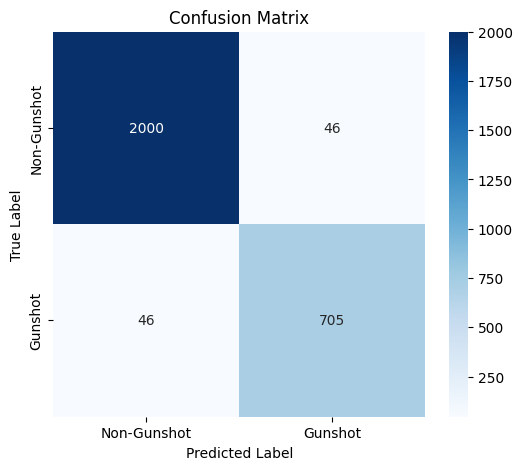

In [ ]:
# Collect predictions and ground truth
val_predictions = []
val_actuals = []

val_gen_eval = audio_data_generator_approach2(X_val, y_val, batch_size=batch_size, shuffle=False)
for _ in range(validation_steps):
    X_batch, y_batch = next(val_gen_eval)
    preds = model.predict(X_batch).flatten()
    val_predictions.extend(preds)
    val_actuals.extend(y_batch)

val_predictions = np.array(val_predictions)
val_actuals = np.array(val_actuals)

threshold = 0.5
val_pred_labels = (val_predictions >= threshold).astype(int)

cm = confusion_matrix(val_actuals, val_pred_labels)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(val_actuals, val_pred_labels, target_names=["Non-Gunshot", "Gunshot"]))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Non-Gunshot", "Gunshot"],
            yticklabels=["Non-Gunshot", "Gunshot"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
